### PART A

In [1]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

In [2]:
X.shape[0]

150

In [3]:
# Create new features
# X is a numpy array it has n rows and four columns, the first index denotes rows and scecond index is the columns
# :, 0 taking all the rows from column 0
x1 = X[:, 0] / X[:, 1]  # sepal length / sepal width
x2 = X[:, 2] / X[:, 3]  # petal length / petal width
X = np.column_stack((x1, x2))

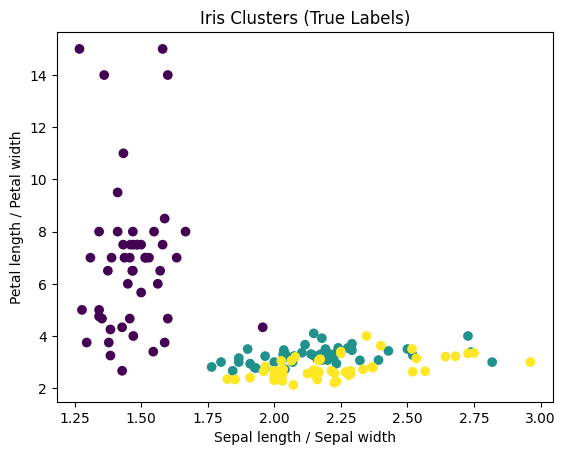

In [4]:
# plotting the data to observe clusters
plt.scatter(X[:, 0], X[:, 1], c=y)
# plt.scatter(x1, x2, c=y)

plt.xlabel('Sepal length / Sepal width')
plt.ylabel('Petal length / Petal width')
plt.title('Iris Clusters (True Labels)')
plt.show()


wanna make x1 and x2 into a (n,2) matrix

In [5]:
X.shape

(150, 2)

In [6]:
from Problem1 import k_means_pp, assign_data2clusters, compute_objective, k_init

### PART B

### PART C

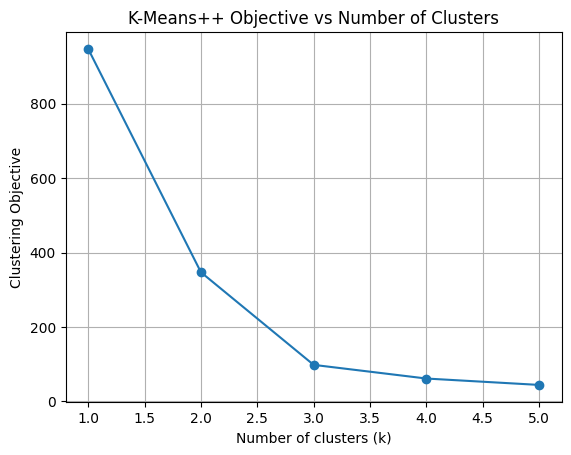

In [7]:
from collections import defaultdict
k_vals = [1, 2, 3, 4, 5]
# values of this dict will be list, intitializes a dictionary as such: accuracy_objectives = dict({1:[], 2:[], 3:[], 4:[], 5:[]})
accuracy_objectives = defaultdict(list)

# run 50 times
for i in range(50):
  for k in (k_vals):
    # run the k means algorithm
    # different k values from 1 to 5
    # objectives = []

    centers, objectives = k_means_pp(X, k, max_iter=50)

    average = np.mean(objectives)
    accuracy_objectives[k].append(average)

# takes average of every key value "k" in the dictionary
for k in accuracy_objectives:
  accuracy_objectives[k] = np.mean(accuracy_objectives[k])

accuracy_objectives = np.array(list(accuracy_objectives.values()))
plt.plot(k_vals, accuracy_objectives, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Clustering Objective")
plt.title("K-Means++ Objective vs Number of Clusters")
plt.grid(True)
plt.show()


### PART D
I believe the final number of clusters should be 3. This is because, while using the elbow method, there is a steady decrease in the loss function, and at 3 is the final point where the clusters are meaningful. At any point past k = 3, the returns from the objective loss function are diminshed.

### PART E

#### 1)

[np.float64(88.49131677185264), np.float64(85.58734112330748), np.float64(85.58734112330748), np.float64(85.58734112330748), np.float64(85.58734112330748), np.float64(85.58734112330748), np.float64(85.58734112330748), np.float64(85.58734112330748), np.float64(85.58734112330748), np.float64(85.58734112330748)]


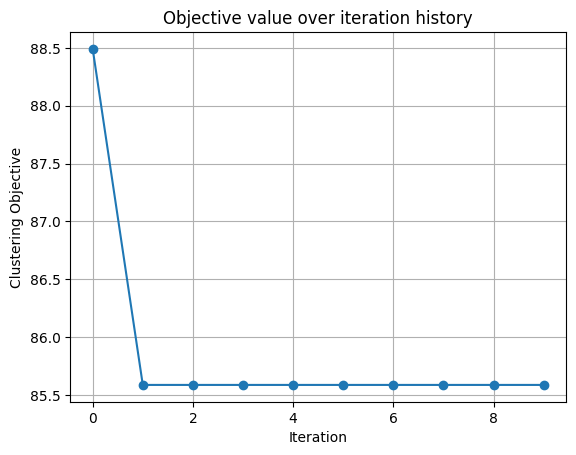

In [8]:
###

accuracy_objectives = []
# run 50 times
k = 3
  # run the k means algorithm

# finds centers and objective functions for our chosen k
centers, objectives = k_means_pp(X, k, max_iter=10)



# gets the average of this objective and plots it per iterations through 50
average = np.mean(objectives)
accuracy_objectives.append(average)
print(objectives)



plt.plot(np.arange(10) , objectives,  marker='o')
plt.xlabel("Iteration")
plt.ylabel("Clustering Objective")
plt.title("Objective value over iteration history")
plt.grid(True)
plt.show()

## should decrease per iteration


##### 2)

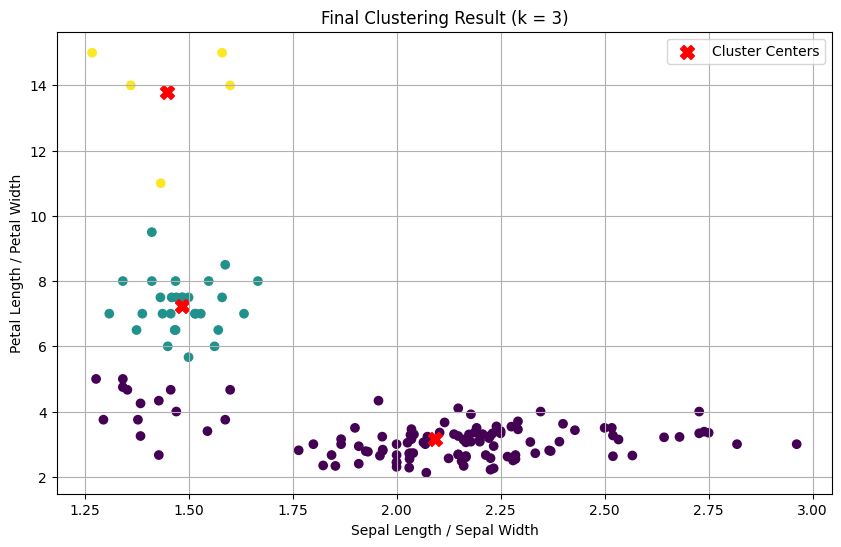

In [9]:

# assignments returns the binary matrix with our data and centers
# data has a 1 in the column of cluster nearest to it
assignments = assign_data2clusters(X, centers)
# converting into array of labels
labels = np.argmax(assignments, axis=1)

# print(centers)


plt.figure(figsize=(10, 6))  # Bigger figure for clarity
plt.scatter(X[:, 0], X[:, 1], c=labels)
# plt.scatter(x1, x2, c=labels)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=100, label='Cluster Centers')
plt.xlabel('Sepal Length / Sepal Width')
plt.ylabel('Petal Length / Petal Width')
plt.title('Final Clustering Result (k = 3)')
plt.legend()
plt.grid(True)
plt.show()

This doesn't work great for this dataset because the original 2 species clusters were on top of each other, and K-MEANS ++ doesn't put them in to clusters. This is a limitation of the algortihm.